# Altona District Profiles 2024

Exploratory data analysis of selected district profile indicators for the borough of Altona, Hamburg.

This notebook complements the script-based workflow in `src/analyze_altona_profiles.py` and is intended as a readable portfolio artifact.


## Scope

- Geographic scope: Altona borough, Hamburg
- Granularity: Stadtteil / district level
- Source context: Hamburger Stadtteil-Profile, reporting year 2024, Statistikamt Nord
- Processed dataset: `data/processed/altona_district_profiles_2024.csv`

This is a descriptive analysis. It does not make causal claims.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "altona_district_profiles_2024.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,district,borough,population,area_km2,population_density,under_18_percent,over_64_percent,unemployment_share_percent_dec_2024,sgb2_share_percent_dec_2024,avg_income_per_taxpayer_2021_eur,general_practitioners_jan_2025,pharmacies_dec_2024,private_cars_per_1000_jan_2025,electric_cars_jan_2025
0,Altona-Altstadt,Altona,29680,2.7,10993,14.9,13.8,8.3,11.4,42848,54,7,218,420
1,Sternschanze,Altona,7669,0.5,15338,12.9,11.0,7.1,7.9,41402,6,3,186,99
2,Altona-Nord,Altona,26777,2.2,12171,16.5,10.6,7.0,9.6,43079,6,4,208,164
3,Ottensen,Altona,35925,2.8,12830,14.7,15.7,5.7,5.5,53126,27,9,257,475
4,Bahrenfeld,Altona,31051,10.5,2957,17.1,13.3,7.9,12.1,45280,12,2,273,878


## Dataset Overview

First, check the size, columns and missing values of the processed dataset.


In [2]:
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print()
print(df.columns.to_list())


Rows: 14
Columns: 14

['district', 'borough', 'population', 'area_km2', 'population_density', 'under_18_percent', 'over_64_percent', 'unemployment_share_percent_dec_2024', 'sgb2_share_percent_dec_2024', 'avg_income_per_taxpayer_2021_eur', 'general_practitioners_jan_2025', 'pharmacies_dec_2024', 'private_cars_per_1000_jan_2025', 'electric_cars_jan_2025']


In [3]:
df.isna().sum()


district                               0
borough                                0
population                             0
area_km2                               0
population_density                     0
under_18_percent                       0
over_64_percent                        0
unemployment_share_percent_dec_2024    0
sgb2_share_percent_dec_2024            0
avg_income_per_taxpayer_2021_eur       0
general_practitioners_jan_2025         0
pharmacies_dec_2024                    0
private_cars_per_1000_jan_2025         0
electric_cars_jan_2025                 0
dtype: int64

## Basic Summary Metrics

The first summary focuses on total population, total area and population-weighted average density.


In [4]:
total_population = int(df["population"].sum())
total_area = float(df["area_km2"].sum())
weighted_density = total_population / total_area

summary = pd.DataFrame(
    {
        "metric": ["districts", "total_population", "total_area_km2", "weighted_density_per_km2"],
        "value": [len(df), total_population, round(total_area, 1), round(weighted_density)],
    }
)

summary


,metric,value
0,districts,14.0
1,total_population,281136.0
2,total_area_km2,77.8
3,weighted_density_per_km2,3614.0


## Population Ranking

The population ranking shows how different district sizes are within the same borough.


In [5]:
population_ranking = df.sort_values("population", ascending=False)[
    ["district", "population", "area_km2", "population_density"]
]

population_ranking


,district,population,area_km2,population_density
7,Lurup,37755,6.3,5993
3,Ottensen,35925,2.8,12830
4,Bahrenfeld,31051,10.5,2957
0,Altona-Altstadt,29680,2.7,10993
2,Altona-Nord,26777,2.2,12171
8,Osdorf,26601,7.3,3644
6,Othmarschen,16528,5.9,2801
13,Rissen,16429,16.7,984
10,Blankenese,13487,7.7,1752
11,Iserbrook,11523,2.7,4268


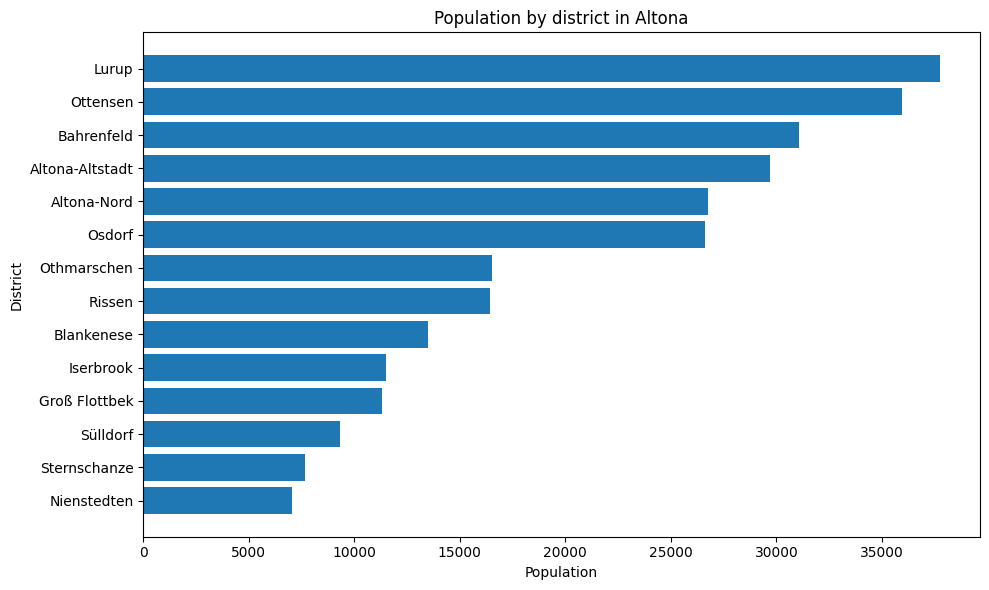

In [6]:
plot_df = df.sort_values("population", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["district"], plot_df["population"])
plt.title("Population by district in Altona")
plt.xlabel("Population")
plt.ylabel("District")
plt.tight_layout()
plt.show()


## Population Density

Population density highlights the difference between compact inner-city districts and lower-density western districts.


In [7]:
density_ranking = df.sort_values("population_density", ascending=False)[
    ["district", "population_density", "population", "area_km2"]
]

density_ranking


,district,population_density,population,area_km2
1,Sternschanze,15338,7669,0.5
3,Ottensen,12830,35925,2.8
2,Altona-Nord,12171,26777,2.2
0,Altona-Altstadt,10993,29680,2.7
7,Lurup,5993,37755,6.3
5,Groß Flottbek,4716,11319,2.4
11,Iserbrook,4268,11523,2.7
8,Osdorf,3644,26601,7.3
4,Bahrenfeld,2957,31051,10.5
6,Othmarschen,2801,16528,5.9


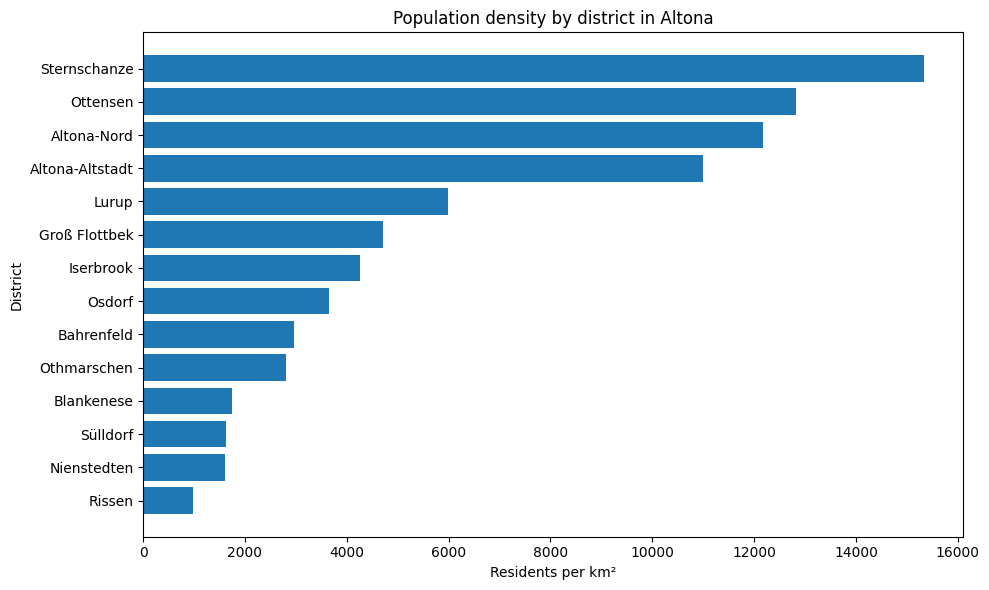

In [8]:
plot_df = df.sort_values("population_density", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["district"], plot_df["population_density"])
plt.title("Population density by district in Altona")
plt.xlabel("Residents per km²")
plt.ylabel("District")
plt.tight_layout()
plt.show()


## Income and Social Indicators

The following view compares average income, unemployment share and SGB II share. This is descriptive only and should not be interpreted as causal.


In [9]:
social_columns = [
    "district",
    "avg_income_per_taxpayer_2021_eur",
    "unemployment_share_percent_dec_2024",
    "sgb2_share_percent_dec_2024",
]

df[social_columns].sort_values("avg_income_per_taxpayer_2021_eur", ascending=False)


,district,avg_income_per_taxpayer_2021_eur,unemployment_share_percent_dec_2024,sgb2_share_percent_dec_2024
9,Nienstedten,168404,2.4,1.0
10,Blankenese,158334,2.6,1.3
5,Groß Flottbek,137079,2.6,1.2
6,Othmarschen,122246,3.3,3.5
13,Rissen,81336,4.6,6.1
8,Osdorf,58530,7.0,11.2
12,Sülldorf,56862,6.0,8.7
11,Iserbrook,53159,4.5,5.6
3,Ottensen,53126,5.7,5.5
4,Bahrenfeld,45280,7.9,12.1


In [10]:
corr_income_sgb2 = df["avg_income_per_taxpayer_2021_eur"].corr(df["sgb2_share_percent_dec_2024"])
corr_income_unemployment = df["avg_income_per_taxpayer_2021_eur"].corr(df["unemployment_share_percent_dec_2024"])

pd.DataFrame(
    {
        "relationship": ["income_vs_sgb2_share", "income_vs_unemployment_share"],
        "correlation": [round(corr_income_sgb2, 2), round(corr_income_unemployment, 2)],
    }
)


,relationship,correlation
0,income_vs_sgb2_share,-0.86
1,income_vs_unemployment_share,-0.91


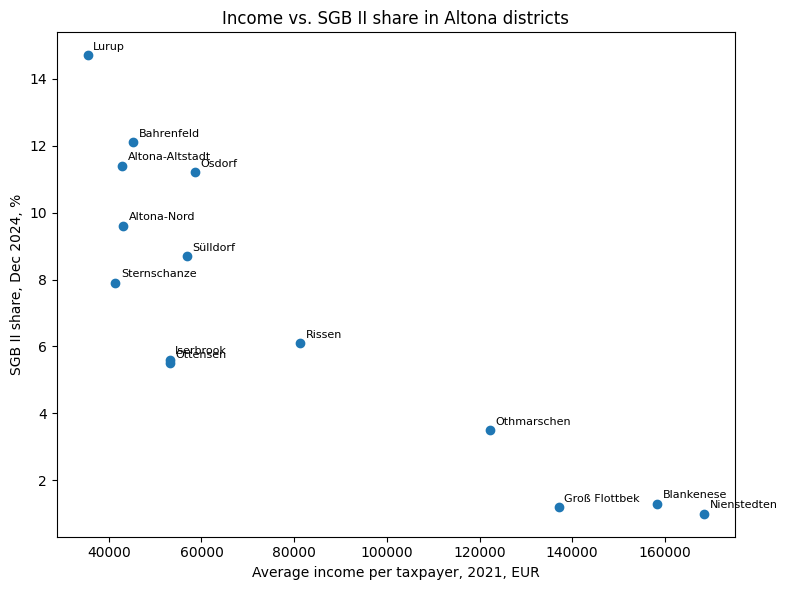

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["avg_income_per_taxpayer_2021_eur"],
    df["sgb2_share_percent_dec_2024"],
)

for _, row in df.iterrows():
    plt.annotate(
        row["district"],
        (row["avg_income_per_taxpayer_2021_eur"], row["sgb2_share_percent_dec_2024"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points",
    )

plt.title("Income vs. SGB II share in Altona districts")
plt.xlabel("Average income per taxpayer, 2021, EUR")
plt.ylabel("SGB II share, Dec 2024, %")
plt.tight_layout()
plt.show()


## Mobility Indicators

Private cars per 1,000 residents and electric car counts are useful descriptive indicators, but they should be interpreted carefully. District density, income levels, household structure, public transport access and land use may all influence car ownership.


In [12]:
mobility_columns = [
    "district",
    "private_cars_per_1000_jan_2025",
    "electric_cars_jan_2025",
    "population_density",
]

df[mobility_columns].sort_values("private_cars_per_1000_jan_2025", ascending=False)


,district,private_cars_per_1000_jan_2025,electric_cars_jan_2025,population_density
9,Nienstedten,502,201,1605
10,Blankenese,489,299,1752
13,Rissen,425,317,984
6,Othmarschen,415,1371,2801
5,Groß Flottbek,414,211,4716
12,Sülldorf,392,149,1637
11,Iserbrook,391,128,4268
8,Osdorf,349,301,3644
7,Lurup,321,345,5993
4,Bahrenfeld,273,878,2957


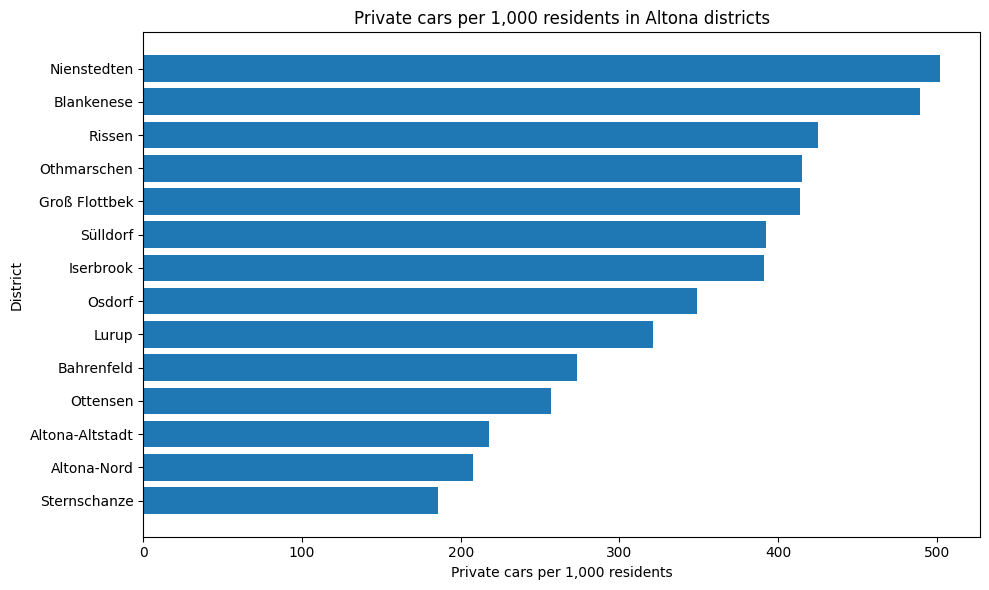

In [13]:
plot_df = df.sort_values("private_cars_per_1000_jan_2025", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["district"], plot_df["private_cars_per_1000_jan_2025"])
plt.title("Private cars per 1,000 residents in Altona districts")
plt.xlabel("Private cars per 1,000 residents")
plt.ylabel("District")
plt.tight_layout()
plt.show()


## Interpretation Limits

- The dataset covers only one Hamburg borough.
- The number of observations is small.
- Indicators refer to different reporting dates.
- Some indicators are absolute counts, while others are rates or ratios.
- Correlations are descriptive and not causal.

This notebook is therefore best understood as a first documented exploration step, not as a complete Hamburg-wide socio-economic analysis.
